In [23]:
%env datadir=/Users/zhijiezhu/Developer/Research/datasets

import argparse
import logging
import pickle as pkl
from collections import defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from lightning import seed_everything
from PIL import Image, ImageDraw
from torch.utils.data import DataLoader, Dataset, Subset
from torcheval.metrics import BinaryAccuracy
from torchvision import tv_tensors
from torchvision.transforms import v2
from tqdm import tqdm

from data import attribute_indices
from eval.local_parts import attributes_indexes
from nets import PPConceptNet
import torch.nn.functional as F


env: datadir=/Users/zhijiezhu/Developer/Research/datasets


In [2]:
class CUBConceptDropDataset(Dataset):
    def __init__(self, data_root: str | Path, drop_attribute_index: int | None, crop_size: int = 50, check_integrity = False):
        self.data_root = Path(data_root)
        self.crop_size = crop_size
        self.drop_attribute_index = drop_attribute_index
        self.check_integrity = check_integrity
        with open(Path("data") / "CUB" / "class_attr_data_10" / "train.pkl", "rb") as fp:
            train_attribute_anns = pkl.load(fp)

        label2attr = dict()
        for ann in train_attribute_anns:
            label, attribute_vector = ann["class_label"], ann["attribute_label"]
            if label not in label2attr:
                label2attr[label] = attribute_vector

        self.attributes = torch.tensor([label2attr[i] for i in range(len(label2attr))], dtype=torch.long)

        with open(Path("data") / "CUB" / "cub_attributes_cleaned.txt", "r") as fp:
            all_attribute_texts = fp.read().splitlines()
        self.attribute_texts = [all_attribute_texts[i] for i in attribute_indices]

        images_df = pd.read_csv(
            Path(self.data_root) / "CUB_200_2011" / "images.txt",
            header=None,
            delimiter=" ",
            names=["img_id", "path"],
            usecols=[0, 1],
            index_col=0
        )
        splits_df = pd.read_csv(
            Path(self.data_root) / "CUB_200_2011" / "train_test_split.txt",
            header=None,
            delimiter=" ",
            names=["img_id", "is_train"],
            usecols=[0, 1],
            index_col=0
        )
        keypoints_df = pd.read_csv(
            Path(self.data_root) / "CUB_200_2011" / "parts"/ "part_locs.txt",
            header=None,
            delimiter=" ",
            names=["img_id", "part_idx", "x", "y"],
            usecols=[0, 1, 2, 3],
            index_col=0
        )
        bbox_df = pd.read_csv(
            Path(self.data_root) / "CUB_200_2011" / "bounding_boxes.txt",
            header=None,
            delimiter=" ",
            names=["img_id", "x", "y", "w", "h"],
            usecols=[0, 1, 2, 3, 4],
            index_col=0
        )
        images_df.index = images_df.index - 1
        splits_df.index = splits_df.index - 1
        keypoints_df.index = keypoints_df.index - 1
        keypoints_df["part_idx"] = keypoints_df["part_idx"] - 1
        bbox_df.index = bbox_df.index - 1

        self.images_df = images_df
        self.splits_df = splits_df
        self.keypoints_df = keypoints_df
        self.bbox_df = bbox_df

        self.samples_df = images_df.loc[splits_df["is_train"] == 0]

        # Process part name to idx mapping
        self.part_name2part_idx = defaultdict(list)
        with open(self.data_root / "CUB_200_2011" / "parts" / "parts.txt", "r") as fp:
            parts = [line.split(" ", 1)[1] for line in fp.read().splitlines()]
        for i, part_name in enumerate(parts):
            self.part_name2part_idx[part_name.split(" ")[-1]].append(i)

        with open(self.data_root / "CUB_200_2011" / "attributes.txt", "r") as fp:
            attributes = fp.read().splitlines()
            attributes = [attributes[i] for i in attributes_indexes]

        with open(self.data_root / "CUB_200_2011" / "parts" / "parts.txt", "r") as fp:
            parts = [line.split(" ", 1)[1] for line in fp.read().splitlines()]

        # Create a mapping from attribute index to part index
        self.attr_id2part_indices = defaultdict(list)
        for attr_idx, attr in enumerate(attributes):
            attr = attr.replace("bill", "beak")
            for part_name, part_indices in self.part_name2part_idx.items():
                if part_name in attr:
                    print("attr", f"{attr_idx}".ljust(3), " "*5, attr.split(" ")[1].ljust(40), "->", " " * 10, part_name)
                    self.attr_id2part_indices[attr_idx] += part_indices

        self.transforms = v2.Compose([
            v2.ToImage(),
            v2.ToDtype(torch.float32, scale=True),
            v2.Normalize((0.485,0.456,0.406,),(0.229,0.224,0.225,),),
        ])

    def __len__(self):
        return len(self.samples_df)

    def __getitem__(self, index: int):
        im_id, im_path = self.samples_df.index[index], self.samples_df.iloc[index]["path"]
        label = int(im_path.split(".")[0]) - 1
        attr = self.attributes[label]

        im = Image.open(self.data_root / "cub200_cropped" / "test_cropped" / im_path)
        im = v2.functional.resize(im, [224, 224])

        if self.drop_attribute_index is None:
            return self.transforms(im), label, attr

        if self.check_integrity:
            assert attr[self.drop_attribute_index] == 1, f"Attribute to drop is not present as ground truth for sample {index}"

        sample_keypoints = self.keypoints_df.loc[
            (self.keypoints_df.index == im_id) &
            (self.keypoints_df["x"] != 0) &
            (self.keypoints_df["y"] != 0)
        ]
        raw_im = Image.open(self.data_root / "CUB_200_2011" / "images" / im_path)
        raw_w, raw_h = raw_im.size
        object_x, object_y, object_w, object_h = tuple(self.bbox_df.iloc[im_id][["x", "y", "w", "h"]])

        # Locate the part keypoints of the attribute, then apply crop and resize transforms on them
        part_indices = set(sample_keypoints['part_idx']) and set(self.attr_id2part_indices[self.drop_attribute_index])
        part_cxcy = sample_keypoints.loc[sample_keypoints["part_idx"].isin(part_indices)][["x", "y"]].to_numpy()
        part_cxcy_pt = tv_tensors.KeyPoints(part_cxcy, canvas_size=(raw_h, raw_w))
        part_cxcy_transformed = v2.functional.crop(part_cxcy_pt, top=object_y, left=object_x, height=object_h, width=object_w)
        part_cxcy_transformed = v2.functional.resize(part_cxcy_transformed, [224, 224])

        draw = ImageDraw.Draw(im)
        for kp in part_cxcy_transformed:
            draw.rectangle(xy=[(kp - self.crop_size // 2).tolist(), (kp + self.crop_size // 2).tolist()], fill="black")
        im_pt = self.transforms(im)

        return im_pt, label, attr

In [3]:
num_classes, num_concepts = 200, 112
data_dir = Path("/Users/zhijiezhu/Developer/Research/datasets")

label2attr = dict()
with open(Path("data") / "CUB" / "class_attr_data_10" / "train.pkl", "rb") as fp:
    train_attribute_anns = pkl.load(fp)

for ann in train_attribute_anns:
    label, attribute_vector = ann["class_label"], ann["attribute_label"]
    if label not in label2attr:
        label2attr[label] = attribute_vector

attributes = torch.tensor([label2attr[i] for i in range(len(label2attr))], dtype=torch.long)

images_df = pd.read_csv(
    Path(data_dir) / "CUB_200_2011" / "images.txt",
    header=None,
    delimiter=" ",
    names=["img_id", "path"],
    usecols=[0, 1],
    index_col=0
)
splits_df = pd.read_csv(
    Path(data_dir) / "CUB_200_2011" / "train_test_split.txt",
    header=None,
    delimiter=" ",
    names=["img_id", "is_train"],
    usecols=[0, 1],
    index_col=0
)
images_df.index = images_df.index - 1
splits_df.index = splits_df.index - 1
images_df["label"] = images_df["path"].str.split(".").str[0].astype(int) - 1
samples_df = pd.concat([images_df, splits_df], axis=1)
samples_df = samples_df.loc[samples_df["is_train"] == 0]

dataset = CUBConceptDropDataset(
    data_root=Path(data_dir),
    drop_attribute_index=None
)
concept_drop_dataset = CUBConceptDropDataset(
    data_root=Path(data_dir),
    drop_attribute_index=0
)

attr 0         has_beak_shape::dagger                   ->            beak
attr 1         has_beak_shape::hooked_seabird           ->            beak
attr 2         has_beak_shape::all-purpose              ->            beak
attr 3         has_beak_shape::cone                     ->            beak
attr 4         has_wing_color::brown                    ->            wing
attr 5         has_wing_color::grey                     ->            wing
attr 6         has_wing_color::yellow                   ->            wing
attr 7         has_wing_color::black                    ->            wing
attr 8         has_wing_color::white                    ->            wing
attr 9         has_wing_color::buff                     ->            wing
attr 22        has_breast_pattern::solid                ->            breast
attr 23        has_breast_pattern::striped              ->            breast
attr 24        has_breast_pattern::multi-colored        ->            breast
attr 25        has_

,part_idx,x,y
img_id,,,
0,1,312.0,182.0
0,4,186.0,45.0
0,5,247.0,79.0
0,9,100.0,221.0
0,10,183.0,101.0
...,...,...,...
11787,10,136.0,133.0
11787,11,102.0,316.0
11787,12,94.0,224.0


In [81]:
kp_df = dataset.keypoints_df.copy()
kp_df = kp_df[(kp_df["x"] != 0) & (kp_df["y"] != 0)]
sample_part_visible = np.zeros((len(dataset.images_df), 15))
for i in range(len(dataset.images_df)):
    visible_part_indices = kp_df[kp_df.index == i]["part_idx"].to_numpy()
    sample_part_visible[i, visible_part_indices] = 1
sample_part_visible = sample_part_visible[dataset.splits_df["is_train"] == 0].astype(bool)

In [120]:
kp_df

,part_idx,x,y
img_id,,,
0,1,312.0,182.0
0,4,186.0,45.0
0,5,247.0,79.0
0,9,100.0,221.0
0,10,183.0,101.0
...,...,...,...
11787,10,136.0,133.0
11787,11,102.0,316.0
11787,12,94.0,224.0


In [119]:
sample_part_visible

array([[False,  True, False, ..., False, False,  True],
       [ True,  True, False, ...,  True,  True,  True],
       [ True,  True, False, ...,  True,  True,  True],
       ...,
       [ True,  True,  True, ..., False,  True,  True],
       [ True,  True,  True, ..., False, False,  True],
       [ True,  True,  True, ...,  True,  True,  True]], shape=(5794, 15))

In [108]:
TOTAL_NUM_PARTS = 15
attr2part = np.zeros(TOTAL_NUM_PARTS).astype(bool)
attr2part[dataset.attr_id2part_indices[0]] = True

attr_i_visible = (sample_part_visible & attr2part).sum(axis=1) > 0

In [116]:
selected_class_indices = torch.nonzero(attributes[:, 0]).flatten().cpu().numpy()
sample_mask = samples_df["label"].isin(selected_class_indices).to_numpy()

sample_mask = sample_mask & attr_i_visible
selected_sample_indices, = np.nonzero(sample_mask)

In [13]:
attr_i = 107

selected_class_indices = torch.nonzero(attributes[:, attr_i]).flatten().cpu().numpy()
sample_mask = samples_df["label"].isin(selected_class_indices).to_numpy()
selected_sample_indices, = np.nonzero(sample_mask)
selected_sample_indices

array([  30,   31,   32,   33,   34,   35,   36,   37,   38,   39,   40,
         41,   42,   43,   44,   45,   46,   47,   48,   49,   50,   51,
         52,   53,   54,   55,   56,   57,   58,   59, 1090, 1091, 1092,
       1093, 1094, 1095, 1096, 1097, 1098, 1099, 1100, 1101, 1102, 1103,
       1104, 1105, 1106, 1107, 1108, 1109, 1110, 1111, 1112, 1113, 1114,
       1115, 1116, 1117, 1118, 1119, 1209, 1210, 1211, 1212, 1213, 1214,
       1215, 1216, 1217, 1218, 1219, 1220, 1221, 1222, 1223, 1224, 1225,
       1226, 1227, 1228, 1229, 1230, 1231, 1232, 1233, 1234, 1235, 1236,
       1237, 1238, 1627, 1628, 1629, 1630, 1631, 1632, 1633, 1634, 1635,
       1636, 1637, 1638, 1639, 1640, 1641, 1642, 1643, 1644, 1645, 1646,
       1647, 1648, 1649, 1650, 1651, 1652, 1653, 1654, 1655, 1656, 1657,
       1658, 1659, 1660, 1661, 1662, 1663, 1664, 1665, 1666, 1667, 1668,
       1669, 1670, 1671, 1672, 1673, 1674, 1675, 1676, 1677, 1678, 1679,
       1680, 1681, 1682, 1683, 1684, 1685, 1686, 16

In [14]:
import matplotlib.pyplot as plt
concept_drop_dataset.drop_attribute_index = attr_i
concept_drop_dataset[1729][0].shape

torch.Size([3, 224, 224])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


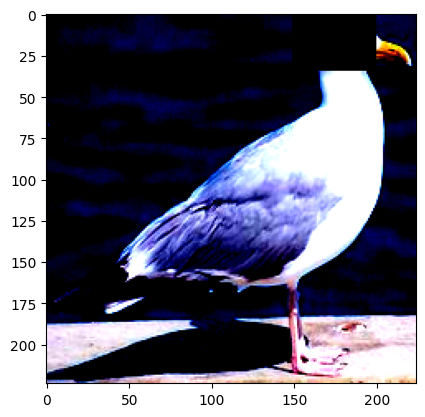

In [15]:
plt.imshow(concept_drop_dataset[1729][0].permute(1, 2, 0).numpy())

In [16]:
{1,2} and {3, 4}

{3, 4}